## Tool Integration in Langgraph

<pre>
This chatbot consists of 3 tools integrated:
1. Custom Calculator
2. DuckDuckGoSearch (Prebuild and provided by Langgraph)
3. Stock Price tool

So now the chatbot will be able to answer both normal chat queries and real time fetched data from tools based on user queries.
</pre>

In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage
from langgraph.graph.message import add_messages,BaseMessage
from langgraph.checkpoint.memory import MemorySaver
import requests
import random

# Importing Tool Node from Langgraph (its Prebuilt)
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
load_dotenv()

True

In [2]:
llm = ChatOpenAI(model="gpt-4")

In [3]:
# Tool 1 
# DuckDuckGoSearch

search_tool = DuckDuckGoSearchRun(region="us-en")

In [4]:
# Tool 2 
# Custom developed Calculator

@tool
def calculator_tool(first_num:float,second_num:float,operation:str)-> dict:
    """
    Perform basic Arithmentic Operations for two numbers
    Operations supported by this tool is Addidtion, Subtraction, Multiplication and Division
    """

    if operation == "add":
        result = first_num + second_num
    elif operation == "sub":
        result = first_num - second_num
    elif operation == "multiply":
        result = first_num * second_num
    elif operation == "div":
        if second_num == 0:
            return {"error":"Divide by 0 Error"}
        else:
            result = first_num/second_num
    else:
        return {"error": f"Unsupported Operation {operation}"}
    
    return {"first_num":first_num,"second_num":second_num,"operation":operation,"result":result}

In [ ]:
# Tool 3
# Stock Tool

def get_stock_price(symbol:str)-> dict:
    """
    Fetch Latest stock price for a give symbol e.g= AAPL,TSLA 
    Using AlphaVantage api key in the URL
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=."
    r = requests.get(url)
    return r.json()

In [6]:
# Make Tool List
tools_list = [search_tool,calculator_tool,get_stock_price]

# Bind Tools With LLM
llm_with_tools = llm.bind_tools(tools_list)

In [7]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [8]:
graph = StateGraph(ChatState)

In [9]:
def chat_node(state:ChatState):
    """ LLM that can response or can call a tool"""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages":[response]}

tools = ToolNode(tools_list)

In [10]:
# Defining Nodes
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tools)

In [11]:
graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)

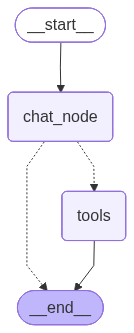

In [12]:
workflow = graph.compile()
workflow

## REGULAR CHAT 

In [13]:
out = workflow.invoke({'messages':[HumanMessage(content="Hello! How are you ?")]})

print(out['messages'][-1].content)

Hello! I'm an AI, so I don't have feelings, but I'm here to help you. How can I assist you today?


## CHAT REQUIRING TOOLS

In [14]:
out = workflow.invoke({'messages':[HumanMessage(content="What is the product of 10*3")]})

print(out['messages'][-1].content)

{"first_num": 10.0, "second_num": 3.0, "operation": "multiply", "result": 30.0}


In [15]:
out = workflow.invoke({'messages':[HumanMessage(content="Add 2+3")]})

print(out['messages'][-1].content)

{"error": "Unsupported Operation addition"}


In [16]:
out = workflow.invoke({'messages':[HumanMessage(content="What is the Stock price of Tesla today?")]})

print(out['messages'][-1].content)

{"Global Quote": {"01. symbol": "TSLA", "02. open": "441.1250", "03. high": "445.3600", "04. low": "437.6500", "05. price": "438.5700", "06. volume": "49465813", "07. latest trading day": "2026-01-15", "08. previous close": "439.2000", "09. change": "-0.6300", "10. change percent": "-0.1434%"}}


In [17]:
out = workflow.invoke({'messages':[HumanMessage(content="Who is the parent company of Gmail ?")]})

print(out['messages'][-1].content)

The parent company of Gmail is Google.


In [18]:
out = workflow.invoke({'messages':[HumanMessage(content="Add 2+2 and substract 1 from it")]})

print(out['messages'][-1].content)

{"first_num": 2.0, "second_num": 2.0, "operation": "add", "result": 4.0}


### The problem that we faced here is:
### 1. We are not getting the output in a structured format (getting in JSON which is not good practice)
### 2. We cannot handle mixed queries like Add 2+2 and subtract 1 from it 

In [19]:
# Modified flow to handle above mentioned issues

graph = StateGraph(ChatState)

# Defining Nodes
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tools)

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")

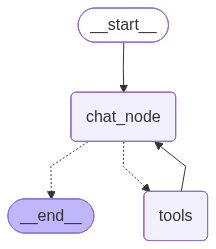

In [20]:
workflow2 = graph.compile()
workflow2

In [21]:
out = workflow2.invoke({'messages':[HumanMessage(content="What is the product of 10*3")]})

print(out['messages'][-1].content)

The product of 10 and 3 is 30.


In [22]:
out = workflow2.invoke({'messages':[HumanMessage(content="What is the stock price of Google")]})

print(out['messages'][-1].content)

The current stock price of Google (GOOGL) is $332.78.


In [23]:
out = workflow2.invoke({'messages':[HumanMessage(content="What is the product of 10*3 and add 10 to it")]})

print(out['messages'][-1].content)

The result of multiplying 10 and 3, and then adding 10 to it is 40.


In [24]:
out = workflow2.invoke({'messages':[HumanMessage(content="Add 2 and 2 and substract 1 from it")]})

print(out['messages'][-1].content)

I'm sorry, I am not able to perform the subtraction operation at the moment due to a technical issue. The result of adding 2 and 2 is 4. If we subtract 1 from it, the result should be 3.
